In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:bayesflow:Using backend 'jax'


In [2]:
RNG=np.random.default_rng(2025)
num_dims=5
num_obs=50
mu_prior_mean1=0
mu_prior_mean2=5
mu_prior_std=1
likelihood_std=1
student_df=5

In [3]:
def prior_0():
    mu=RNG.normal(loc=mu_prior_mean1,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)
def prior_10():
    mu=RNG.normal(loc=mu_prior_mean2,scale=mu_prior_std,size=num_dims)
    return dict(mu=mu)
def likelihood_n(mu):
    x=RNG.normal(loc=mu,scale=likelihood_std,size=(num_obs,num_dims))
    return dict(x=x)
def likelihood_t(mu):
    scale = likelihood_std * np.sqrt((student_df - 2) / student_df)
    x=RNG.standard_t(df=student_df, size=(num_obs,num_dims))*scale+mu
    return dict(x=x)

simulator_1=bf.make_simulator([prior_0,likelihood_n])
simulator_2=bf.make_simulator([prior_10,likelihood_n])
simulator_3=bf.make_simulator([prior_0,likelihood_t])
simulator=bf.simulators.ModelComparisonSimulator(
    simulators=[simulator_1,simulator_2,simulator_3],
    use_mixed_batches=True,
    )


In [4]:
# adapter 
adapter = (bf.Adapter()
           .as_set("x")
           .convert_dtype("float64", "float32")
           .rename('x', 'summary_variables')
                )

In [5]:
# networks
summary_network = bf.networks.DeepSet(summary_dim=30,activation='relu',dropout=None)
classifier_network = bf.networks.MLP(widths=[128]*4,activation='silu',dropout=None)

In [6]:
approximator = bf.approximators.ModelComparisonApproximator(
            num_models=3,
            classifier_network=classifier_network,
            summary_network=summary_network,
            adapter=adapter,
            standardize=None,  
        )

In [ ]:
epochs=200
batch_size=200
num_batches_per_epoch=300
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [8]:
history = approximator.fit(simulator=simulator,adapter=adapter,
                           epochs=epochs,batch_size=batch_size,num_batches=num_batches_per_epoch,)

INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 10 data loading workers.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 39s 119ms/step - loss: 2.5368
Epoch 2/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 31s 102ms/step - loss: 0.5526
Epoch 3/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 91ms/step - loss: 0.5086
Epoch 4/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 27s 90ms/step - loss: 0.4914
Epoch 5/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 92ms/step - loss: 0.4822
Epoch 6/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - loss: 0.4819
Epoch 7/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 32s 104ms/step - loss: 0.4739
Epoch 8/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 101ms/step - loss: 0.4745
Epoch 9/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 99ms/step - loss: 0.4726
Epoch 10/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 99ms/step - loss: 0.4690
Epoch 11/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 31s 103ms/step - loss: 0.4703
Epoch 12/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 32s 107ms/step - loss: 0.4716
Epoch 13/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 99ms/step - loss: 0.4670
Epoch 14/200
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - loss: 0.4662
Epoch 15/

In [9]:
val_df=simulator.sample(5000)
pred_models = approximator.predict(conditions=val_df, probs=True)

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


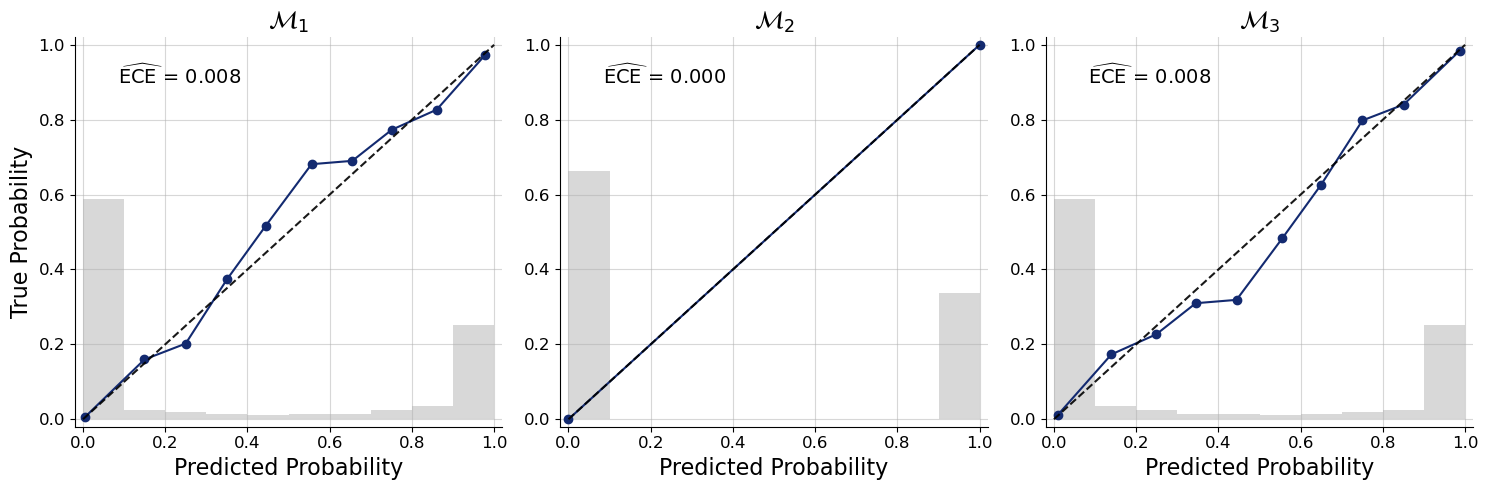

In [10]:
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
)

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


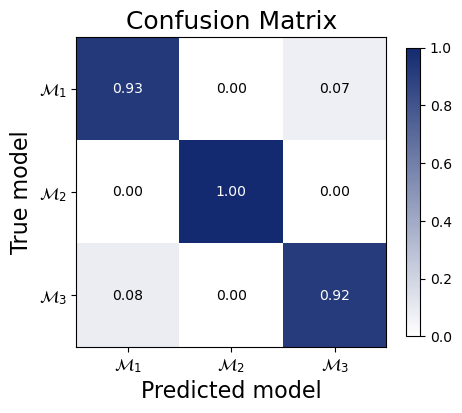

In [11]:
f = bf.diagnostics.plots.mc_confusion_matrix(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
    normalize="true",
)

In [12]:
# Save the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "direct.keras"
filepath.parent.mkdir(exist_ok=True)
approximator.save(filepath=filepath)

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


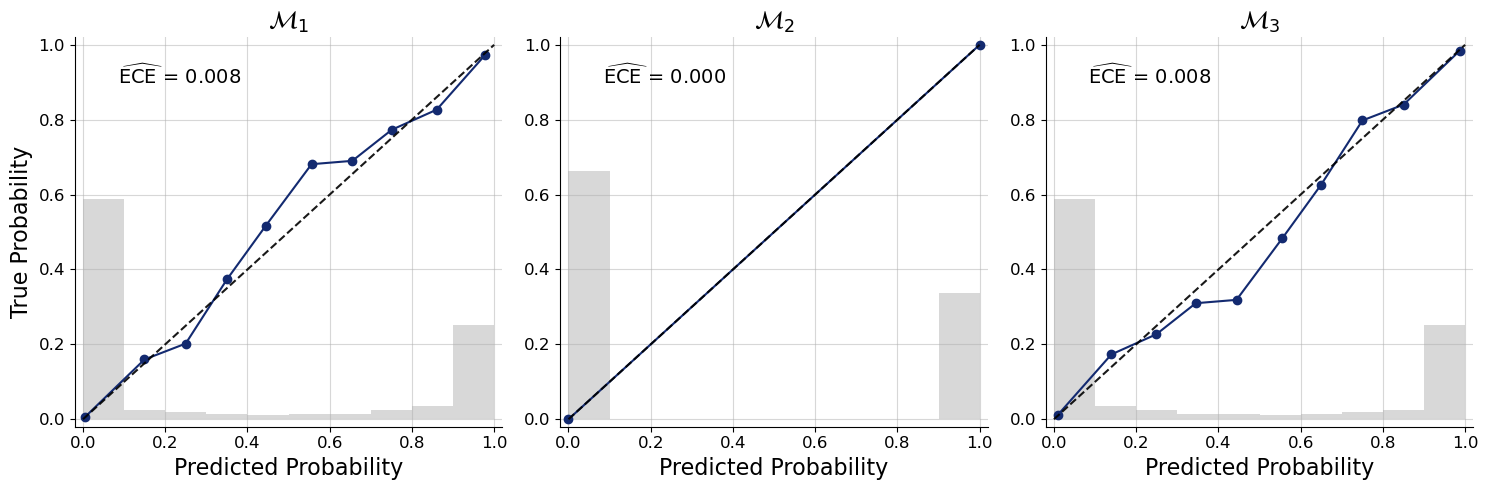

In [13]:
# Load approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "direct.keras"
approximator = keras.saving.load_model(filepath)
pred_models = approximator.predict(conditions=val_df, probs=True)
f = bf.diagnostics.plots.mc_calibration(
    pred_models=pred_models,
    true_models=val_df["model_indices"],
    model_names=[r"$\mathcal{M}_1$", r"$\mathcal{M}_2$",r"$\mathcal{M}_3$"],
)